In [ ]:
from google.colab import files
files.upload()

import os, shutil
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)


!pip install -q kaggle
!kaggle --version

!kaggle datasets list -s skin-cancer
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

import os
print(os.listdir('.'))


Saving kaggle.json to kaggle (1).json
Kaggle API 1.7.4.5
ref                                                               title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                 Skin Cancer MNIST: HAM10000                     5582914511  2018-09-20 20:36:13.037000         215870       2145  0.7058824        
nodoubttome/skin-cancer9-classesisic                              Skin Cancer ISIC                                1647873564  2019-08-26 18:59:21.257000          28276        279  0.75             
surajghuwalewala/ham1000-segmentation-and-classification          Skin cancer: HAM10000                           2781385274  2021-05-27 09:08:46.81300

In [ ]:
#Unzip the dataset
!unzip skin-cancer-mnist-ham10000.zip -d /content/ham10000

# List first several files/folders inside extracted dataset
import os
print(os.listdir('/content/ham10000'))

Streaming output truncated to the last 5000 lines.
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029326.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029327.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029328.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029329.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029330.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029331.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029332.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029333.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029334.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029335.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029336.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029337.jpg  
  inflating: /content/ham10000/ham10000_images_part_2/ISIC_0029338.jpg  


In [ ]:
import pandas as pd
import os

meta_path = '/content/ham10000/HAM10000_metadata.csv'
df = pd.read_csv(meta_path)
print(df.head())
print(f"Total samples: {len(df)}")
print(f"Unique lesion types: {df['dx'].nunique()} - {df['dx'].unique()}")

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Total samples: 10015
Unique lesion types: 7 - ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [ ]:
labelnames = sorted(df['dx'].unique())
label2idx = {label: idx for idx, label in enumerate(labelnames)}
idx2label = {idx: label for label, idx in label2idx.items()}
df['label_idx'] = df['dx'].map(label2idx)


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label_idx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_idx'], random_state=42)
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")


Train: 7010, Validation: 1502, Test: 1503


In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

img_dir = '/content/ham10000/'

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

class SkinCancerDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_id'] + '.jpg')
        image = Image.open(img_path).convert('RGB')
        label = row['label_idx']
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
batch_size = 16

train_dataset = SkinCancerDataset(train_df, img_dir, transform=train_transform)
val_dataset = SkinCancerDataset(val_df, img_dir, transform=val_transform)
test_dataset = SkinCancerDataset(test_df, img_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(label2idx)
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=num_classes)
model = model.to(device)

# Optional: class weights to handle imbalanced classes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for inputs, labels in tqdm(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion):
    model.eval()
    running_loss, running_corrects, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

In [ ]:
import os
base_path = '/content/ham10000'
print(os.listdir(base_path))  # Check subfolders or files

['HAM10000_images_part_2', 'HAM10000_metadata.csv', 'ham10000_images_part_2', 'hmnist_8_8_RGB.csv', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1']


In [ ]:
import os
from PIL import Image

class SkinCancerDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.part1_dir = os.path.join(base_dir, 'HAM10000_images_part_1')
        self.part2_dir = os.path.join(base_dir, 'HAM10000_images_part_2')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id'] + '.jpg'
        img_path1 = os.path.join(self.part1_dir, img_name)
        img_path2 = os.path.join(self.part2_dir, img_name)

        if os.path.exists(img_path1):
            img_path = img_path1
        elif os.path.exists(img_path2):
            img_path = img_path2
        else:
            raise FileNotFoundError(f"Image not found: {img_name}")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = row['label_idx']
        return image, label


In [ ]:
base_dir = '/content/ham10000'
train_dataset = SkinCancerDataset(train_df, base_dir, transform=train_transform)
val_dataset = SkinCancerDataset(val_df, base_dir, transform=val_transform)
test_dataset = SkinCancerDataset(test_df, base_dir, transform=val_transform)


In [ ]:
import os
from PIL import Image

class SkinCancerDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.part1_dir = os.path.join(base_dir, 'HAM10000_images_part_1')
        self.part2_dir = os.path.join(base_dir, 'HAM10000_images_part_2')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id'] + '.jpg'
        img_path1 = os.path.join(self.part1_dir, img_name)
        img_path2 = os.path.join(self.part2_dir, img_name)

        if os.path.exists(img_path1):
            img_path = img_path1
        elif os.path.exists(img_path2):
            img_path = img_path2
        else:
            raise FileNotFoundError(f"Image not found: {img_name}")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = row['label_idx']
        return image, label

base_dir = '/content/ham10000'
train_dataset = SkinCancerDataset(train_df, base_dir, transform=train_transform)
val_dataset = SkinCancerDataset(val_df, base_dir, transform=val_transform)
test_dataset = SkinCancerDataset(test_df, base_dir, transform=val_transform)


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

# GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load metadata
base_dir = '/content/ham10000'
meta_csv = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(meta_csv)

# Map label to numeric class
labelnames = sorted(df['dx'].unique())
label2idx = {label: idx for idx, label in enumerate(labelnames)}
df['label_idx'] = df['dx'].map(label2idx)

# Train-validation-test split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label_idx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_idx'], random_state=42)

# Dataset class
class SkinCancerDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.part1_dir = os.path.join(base_dir, 'HAM10000_images_part_1')
        self.part2_dir = os.path.join(base_dir, 'HAM10000_images_part_2')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id'] + '.jpg'
        img_path1 = os.path.join(self.part1_dir, img_name)
        img_path2 = os.path.join(self.part2_dir, img_name)

        if os.path.exists(img_path1):
            img_path = img_path1
        elif os.path.exists(img_path2):
            img_path = img_path2
        else:
            raise FileNotFoundError(f"Image not found: {img_name}")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = row['label_idx']
        return image, label

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets and dataloaders
batch_size = 16
train_dataset = SkinCancerDataset(train_df, base_dir, transform=train_transform)
val_dataset = SkinCancerDataset(val_df, base_dir, transform=val_transform)
test_dataset = SkinCancerDataset(test_df, base_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Model, criterion, optimizer setup
num_classes = len(label2idx)
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes).to(device)

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label_idx']), y=train_df['label_idx'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# Training and validation functions
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for inputs, labels in tqdm(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion):
    model.eval()
    running_loss, running_corrects, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

# Training loop
num_epochs = 15
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_convnext_model.pth")
        print("Best model saved!")


100%|██████████| 439/439 [01:14<00:00,  5.89it/s]


Epoch 1/15 - Train Loss: 1.8305, Train Acc: 0.4157, Val Loss: 1.5566, Val Acc: 0.3742
Best model saved!


100%|██████████| 439/439 [00:58<00:00,  7.52it/s]


Epoch 2/15 - Train Loss: 1.3377, Train Acc: 0.5605, Val Loss: 1.0846, Val Acc: 0.6804
Best model saved!


100%|██████████| 439/439 [00:59<00:00,  7.35it/s]


...

Epoch 13/15 - Train Loss: 0.0874, Train Acc: 0.9305, Val Loss: 1.1662, Val Acc: 0.8202
Best model saved!


100%|██████████| 439/439 [00:57<00:00,  7.67it/s]


Epoch 14/15 - Train Loss: 0.0696, Train Acc: 0.9448, Val Loss: 1.2110, Val Acc: 0.8522
Best model saved!


100%|██████████| 439/439 [00:56<00:00,  7.71it/s]


Epoch 15/15 - Train Loss: 0.0631, Train Acc: 0.9526, Val Loss: 1.2303, Val Acc: 0.8422


              precision    recall  f1-score   support

       akiec       0.62      0.76      0.68        49
         bcc       0.80      0.71      0.75        77
         bkl       0.65      0.73      0.69       165
          df       0.91      0.59      0.71        17
         mel       0.57      0.66      0.61       167
          nv       0.94      0.90      0.92      1006
        vasc       0.90      0.82      0.86        22

    accuracy                           0.83      1503
   macro avg       0.77      0.74      0.75      1503
weighted avg       0.85      0.83      0.84      1503



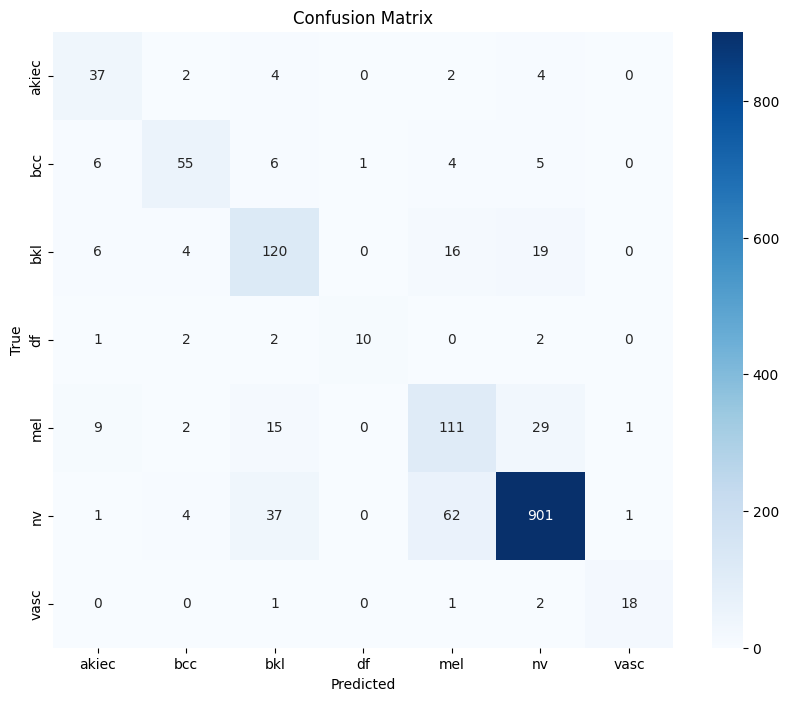

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load model checkpoint
model.load_state_dict(torch.load("/content/best_convnext_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
print(classification_report(all_labels, all_preds, target_names=labelnames))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labelnames, yticklabels=labelnames)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load metadata
base_dir = '/content/ham10000'
meta_csv = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(meta_csv)

# Label mapping
labelnames = sorted(df['dx'].unique())
label2idx = {label: idx for idx, label in enumerate(labelnames)}
df['label_idx'] = df['dx'].map(label2idx)

# Train-validation-test split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label_idx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_idx'], random_state=42)

# Dataset class with flexible image folder loading
class SkinCancerDataset(Dataset):
    def __init__(self, df, base_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.part1_dir = os.path.join(base_dir, 'HAM10000_images_part_1')
        self.part2_dir = os.path.join(base_dir, 'HAM10000_images_part_2')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image_id'] + '.jpg'
        img_path1 = os.path.join(self.part1_dir, img_name)
        img_path2 = os.path.join(self.part2_dir, img_name)

        if os.path.exists(img_path1):
            img_path = img_path1
        elif os.path.exists(img_path2):
            img_path = img_path2
        else:
            raise FileNotFoundError(f"Image not found: {img_name}")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        label = row['label_idx']
        return image, label

# Augmentation - advanced for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = SkinCancerDataset(train_df, base_dir, transform=train_transform)
val_dataset = SkinCancerDataset(val_df, base_dir, transform=val_transform)
test_dataset = SkinCancerDataset(test_df, base_dir, transform=val_transform)

# Balanced sampling for training
class_sample_counts = train_df['label_idx'].value_counts().sort_index().to_list()
weights = 1. / torch.tensor(class_sample_counts, dtype=torch.float)
samples_weights = weights[train_df['label_idx'].values]
sampler = WeightedRandomSampler(weights=samples_weights, num_samples=len(samples_weights), replacement=True)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Label smoothing loss - implemented as cross entropy with soft targets
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    def forward(self, logits, target):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

# Model setup with larger ConvNeXt variant
num_classes = len(label2idx)
model = timm.create_model('convnext_small', pretrained=True, num_classes=num_classes).to(device)

criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler with warm-up and cosine annealing with warm restarts
def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5, last_epoch=-1):
    from torch.optim.lr_scheduler import _LRScheduler
    import math
    class CosineWithWarmup(_LRScheduler):
        def __init__(self, optimizer, num_warmup_steps, num_training_steps, num_cycles=0.5, last_epoch=-1):
            self.num_warmup_steps = num_warmup_steps
            self.num_training_steps = num_training_steps
            self.num_cycles = num_cycles
            super().__init__(optimizer, last_epoch)
        def get_lr(self):
            if self.last_epoch < self.num_warmup_steps:
                return [base_lr * float(self.last_epoch) / float(max(1, self.num_warmup_steps)) for base_lr in self.base_lrs]
            progress = float(self.last_epoch - self.num_warmup_steps) / float(max(1, self.num_training_steps - self.num_warmup_steps))
            return [base_lr * 0.5 * (1.0 + math.cos(math.pi * self.num_cycles * 2.0 * progress)) for base_lr in self.base_lrs]
    return CosineWithWarmup(optimizer, num_warmup_steps, num_training_steps, num_cycles)

num_epochs = 10
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

# Training and validation functions
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler):
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0
    for inputs, labels in tqdm(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion):
    model.eval()
    running_loss, running_corrects, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)
    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

# Training loop
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_convnext_model.pth")
        print("Best model saved!")


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

100%|██████████| 585/585 [01:33<00:00,  6.23it/s]


Epoch 1/10 - Train Loss: 1.1710, Train Acc: 0.6491, Val Loss: 1.0353, Val Acc: 0.6831
Best model saved!


100%|██████████| 585/585 [01:42<00:00,  5.72it/s]


Epoch 2/10 - Train Loss: 0.8343, Train Acc: 0.8163, Val Loss: 0.9356, Val Acc: 0.7344
Best model saved!


...

Epoch 8/10 - Train Loss: 0.4883, Train Acc: 0.9809, Val Loss: 0.7507, Val Acc: 0.8648
Best model saved!


100%|██████████| 585/585 [01:29<00:00,  6.52it/s]


Epoch 9/10 - Train Loss: 0.4729, Train Acc: 0.9892, Val Loss: 0.7225, Val Acc: 0.8755
Best model saved!


100%|██████████| 585/585 [01:29<00:00,  6.53it/s]


Epoch 10/10 - Train Loss: 0.4664, Train Acc: 0.9910, Val Loss: 0.7332, Val Acc: 0.8735


Test Accuracy: 0.8589
              precision    recall  f1-score   support

       akiec       0.89      0.65      0.75        49
         bcc       0.73      0.84      0.78        77
         bkl       0.73      0.75      0.74       165
          df       1.00      0.59      0.74        17
         mel       0.65      0.69      0.67       167
          nv       0.93      0.92      0.92      1006
        vasc       0.86      0.82      0.84        22

    accuracy                           0.86      1503
   macro avg       0.83      0.75      0.78      1503
weighted avg       0.86      0.86      0.86      1503



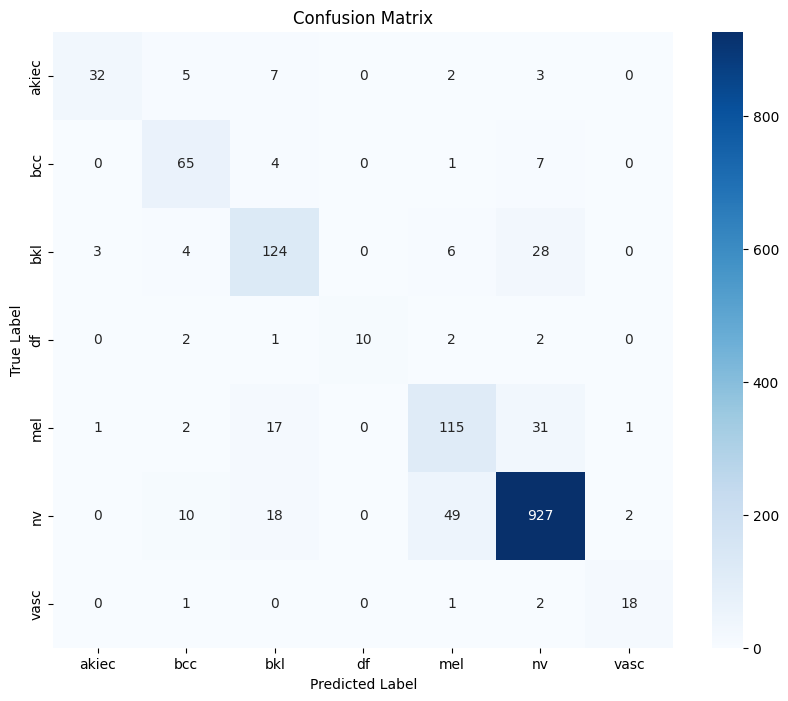

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load saved best model
model.load_state_dict(torch.load("/content/best_convnext_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall accuracy
acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}")

# Detailed classification report
print(classification_report(all_labels, all_preds, target_names=labelnames))

# Confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labelnames, yticklabels=labelnames)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import os
import random

base_dir = '/content/ham10000'
part1_dir = os.path.join(base_dir, 'HAM10000_images_part_1')
part2_dir = os.path.join(base_dir, 'HAM10000_images_part_2')

# List images in part1 and part2 folders
part1_images = [os.path.join(part1_dir, f) for f in os.listdir(part1_dir) if f.endswith('.jpg')]
part2_images = [os.path.join(part2_dir, f) for f in os.listdir(part2_dir) if f.endswith('.jpg')]
all_images = part1_images + part2_images

# Pick a random image
random_image_path = random.choice(all_images)
print(f"Classifying random image: {random_image_path}")

# Now call your classify_nv_non_nv:
label, confidence = classify_nv_non_nv(random_image_path)
print(f"Prediction: {label} with confidence {confidence:.4f}")


Classifying random image: /content/ham10000/HAM10000_images_part_1/ISIC_0029207.jpg
Prediction: nv with confidence 0.9163


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 112.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you h

True lesion label: nv
Predicted lesion label: nv


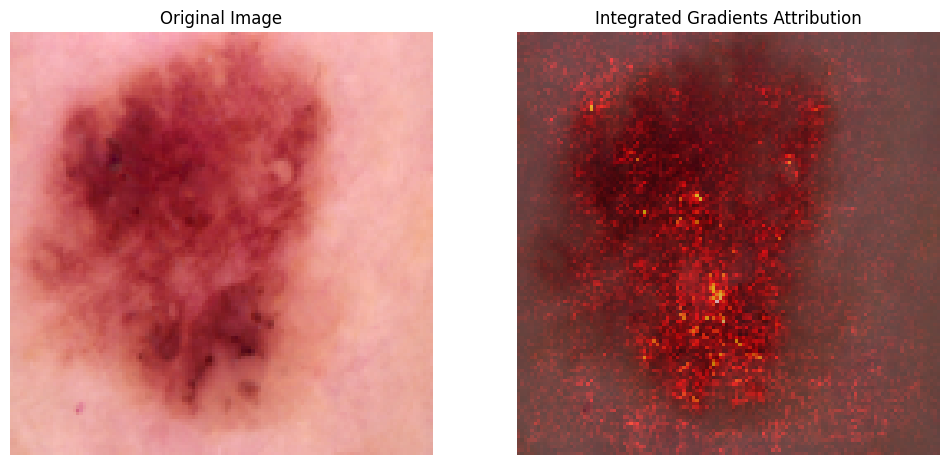

In [ ]:
# Step 1: Install Captum
!pip install captum

# Step 2: Import libraries and define visualization functions
from captum.attr import IntegratedGradients
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch

ig = IntegratedGradients(model)

def visualize_integrated_gradients(img_tensor, label_idx):
    model.eval()
    attributions, delta = ig.attribute(img_tensor.unsqueeze(0).to(device),
                                       target=label_idx,
                                       return_convergence_delta=True)
    attr = attributions.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    attr_sum = np.sum(np.abs(attr), axis=2)
    attr_sum = (attr_sum - attr_sum.min()) / (attr_sum.max() - attr_sum.min())

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Integrated Gradients Attribution")
    plt.imshow(img)
    plt.imshow(attr_sum, cmap="hot", alpha=0.6)
    plt.axis('off')
    plt.show()

# Step 3: Pick random image from test dataset and visualize
import random
idx = random.randint(0, len(test_dataset)-1)
img_tensor, true_label = test_dataset[idx]

print("True lesion label:", labelnames[true_label])
preds = model(img_tensor.unsqueeze(0).to(device))
pred_label = torch.argmax(preds, dim=1).item()
print("Predicted lesion label:", labelnames[pred_label])

visualize_integrated_gradients(img_tensor, pred_label)


True lesion label: nv
Predicted lesion label: nv


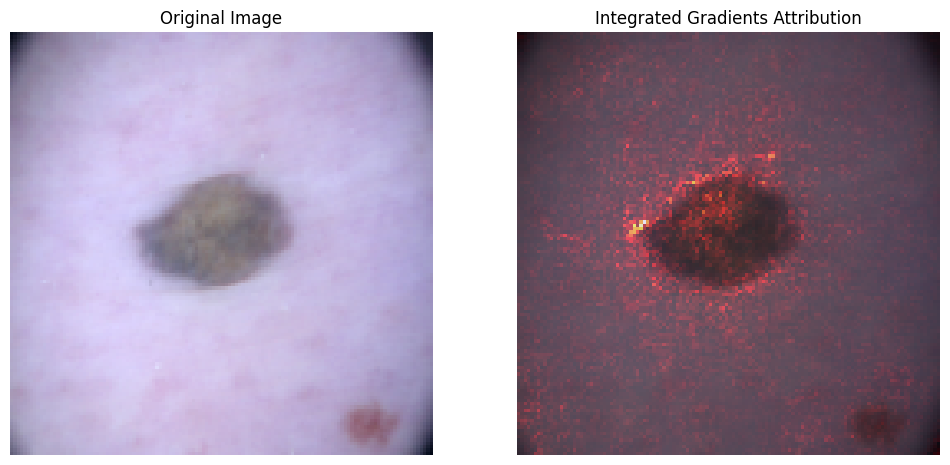

In [ ]:
from captum.attr import IntegratedGradients
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import torch

ig = IntegratedGradients(model)

def visualize_integrated_gradients(img_tensor, label_idx):
    model.eval()
    attributions, delta = ig.attribute(img_tensor.unsqueeze(0).to(device),
                                       target=label_idx,
                                       return_convergence_delta=True)
    attr = attributions.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    attr_sum = np.sum(np.abs(attr), axis=2)
    attr_sum = (attr_sum - attr_sum.min()) / (attr_sum.max() - attr_sum.min())

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Integrated Gradients Attribution")
    plt.imshow(img)
    plt.imshow(attr_sum, cmap="hot", alpha=0.6)
    plt.axis('off')
    plt.show()

# Step 3: Pick random image from test dataset and visualize
import random
idx = random.randint(0, len(test_dataset)-1)
img_tensor, true_label = test_dataset[idx]

print("True lesion label:", labelnames[true_label])
preds = model(img_tensor.unsqueeze(0).to(device))
pred_label = torch.argmax(preds, dim=1).item()
print("Predicted lesion label:", labelnames[pred_label])

visualize_integrated_gradients(img_tensor, pred_label)

Classifying and displaying image: /content/ham10000/HAM10000_images_part_1/ISIC_0027733.jpg


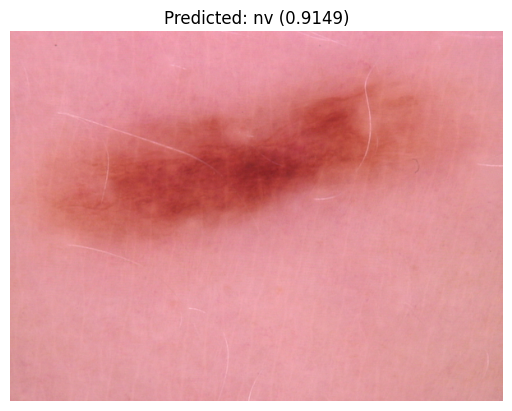

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Preprocessing same as validation/test
preprocess = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def classify_and_show(image_path):
    image = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    predicted_label = labelnames[pred_idx.item()]
    confidence = conf.item()

    # Show image and prediction
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label} ({confidence:.4f})")
    plt.axis('off')
    plt.show()

# Pick random image
random_image_path = random.choice(part1_images + part2_images)
print(f"Classifying and displaying image: {random_image_path}")

classify_and_show(random_image_path)


Using image: /content/ham10000/HAM10000_images_part_1/ISIC_0027013.jpg
Model prediction: nv


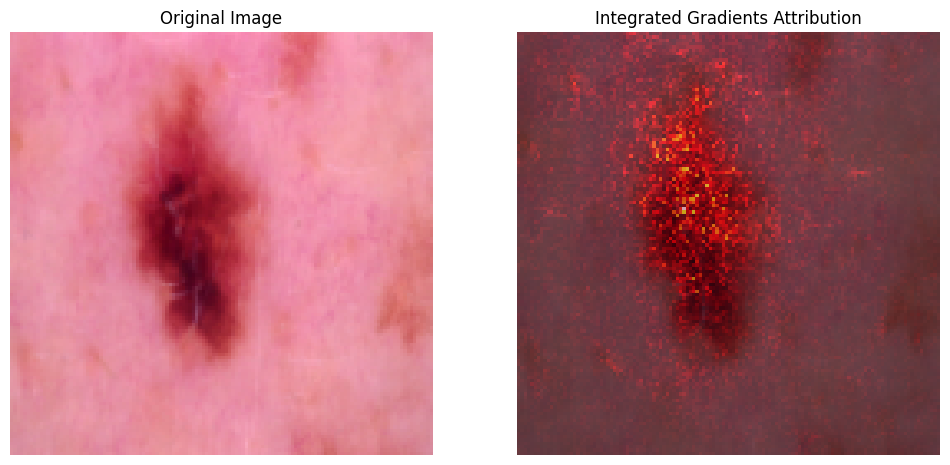

In [ ]:
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from PIL import Image

# Assume model, device, labelnames, preprocess are defined

ig = IntegratedGradients(model)

def visualize_integrated_gradients(img_tensor, label_idx):
    model.eval()
    attributions, delta = ig.attribute(img_tensor.unsqueeze(0).to(device),
                                       target=label_idx,
                                       return_convergence_delta=True)
    attr = attributions.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    attr_sum = np.sum(np.abs(attr), axis=2)
    attr_sum = (attr_sum - attr_sum.min()) / (attr_sum.max() - attr_sum.min())

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Integrated Gradients Attribution")
    plt.imshow(img)
    plt.imshow(attr_sum, cmap="hot", alpha=0.6)
    plt.axis('off')
    plt.show()

# Pick a random image from dataset folders
import random
random_image_path = random.choice(part1_images + part2_images)
print(f"Using image: {random_image_path}")

# Prepare image tensor
image = Image.open(random_image_path).convert('RGB')
img_tensor = preprocess(image)

# Predict label for the image
logits = model(img_tensor.unsqueeze(0).to(device))
pred_label = torch.argmax(logits, dim=1).item()
print(f"Model prediction: {labelnames[pred_label]}")

# Visualize Integrated Gradients attribution
visualize_integrated_gradients(img_tensor, pred_label)